# Advisory Prediction — Gradient Boosted Tree

This notebook trains a gradient-boosted tree (XGBoost) to predict whether a **swimming advisory should be active** over a future window,
given a CSV of past days of site-level water-quality and weather data.

**True label**: `advisory_active` — derived directly from the advisory event metadata in the panel.
No information from `onset_label`, `termination_label`, sign-posting, or current advisory status is used as a feature (leakage guard).

**Category split**: the model is trained and evaluated separately for `Category_1` and `Category_2` sites,
but a combined model is also produced as a baseline.

**Temporal split**: train on 2020–2023, validate on 2024, test on 2025 — no random shuffling across time.

In [3]:
# ── 0. Imports & config ──────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

# ── paths ────────────────────────────────────────────────────────────────────
DATA_PATH = '../processed_data/site_day_panel.csv'   # update if needed

# ── temporal split boundaries ────────────────────────────────────────────────
TRAIN_END   = '2023-12-31'
VAL_START   = '2024-01-01'
VAL_END     = '2024-12-31'
TEST_START  = '2025-01-01'

# ── prediction target ────────────────────────────────────────────────────────
TARGET = 'advisory_active'

# ── future window (days) for rolling-horizon labelling ───────────────────────
# When FUTURE_WINDOW > 0, the label becomes:
#   "will advisory_active == 1 on ANY of the next N calendar days?"
# Set to 0 to predict the *same-day* label instead.
FUTURE_WINDOW = 7

print('XGBoost version:', xgb.__version__)
print('pandas version:', pd.__version__)

XGBoost version: 3.2.0
pandas version: 3.0.2


## 1 — Load & inspect

In [4]:
# ── 1. Load ───────────────────────────────────────────────────────────────────
df_raw = pd.read_csv(DATA_PATH, low_memory=False, parse_dates=['date'])
df_raw = df_raw.sort_values(['site_name', 'date']).reset_index(drop=True)

print(f'Shape: {df_raw.shape}')
print(f'Date range: {df_raw["date"].min().date()} → {df_raw["date"].max().date()}')
print()
print('Sites per category:')
print(df_raw.groupby('major_category')['site_name'].nunique())
print()
print('advisory_active distribution:')
print(df_raw[TARGET].value_counts(normalize=True).rename({0:'no advisory', 1:'advisory'}).to_string())

Shape: (21920, 178)
Date range: 2020-01-01 → 2025-12-31

Sites per category:
major_category
Category_1    8
Category_2    2
Name: site_name, dtype: int64

advisory_active distribution:
advisory_active
no advisory    0.569754
advisory       0.430246


## 2 — Build the true label

The panel already contains `advisory_active` (0/1) derived from the event metadata,
with leakage-prone sign/status columns deliberately excluded.

For **future-window prediction** we roll the label forward: the label for row *t* becomes
*"was advisory active on any day in (t, t+FUTURE_WINDOW]?"*
This is done **per site** so labels never bleed across water bodies.

In [5]:
# ── 2. Build forward-window label ────────────────────────────────────────────
def make_future_label(group: pd.DataFrame, window: int) -> pd.Series:
    """
    For each row, return 1 if advisory_active == 1 on any of the next
    `window` calendar days for the *same site*.
    Rows where a full window cannot be formed are set to NaN (dropped later).
    """
    s = group[TARGET].values
    label = np.empty(len(s))
    label[:] = np.nan
    for i in range(len(s) - window):
        label[i] = int(np.any(s[i + 1 : i + 1 + window]))
    return pd.Series(label, index=group.index)


if FUTURE_WINDOW > 0:
    df_raw['label'] = (
        df_raw.groupby('site_name', group_keys=False)
              .apply(lambda g: make_future_label(g, FUTURE_WINDOW))
    )
    label_desc = f'advisory in next {FUTURE_WINDOW} days'
else:
    df_raw['label'] = df_raw[TARGET].astype(float)
    label_desc = 'advisory active today'

n_valid = df_raw['label'].notna().sum()
pos_rate = df_raw['label'].mean()
print(f'Label: {label_desc}')
print(f'Rows with valid label: {n_valid:,}  |  positive rate: {pos_rate:.2%}')

Label: advisory in next 7 days
Rows with valid label: 21,850  |  positive rate: 43.66%


## 3 — Feature engineering

We drop all columns that would constitute leakage:
- `onset_label`, `termination_label` — these *are* the event boundaries  
- `advisory_active` — the raw label we just extracted  
- `advisory_event_id`, `advisory_event_censored`, `advisory_event_termination_observed`  
- Any sampling-time strings (`earliest_sample_time`, `latest_sample_time`)

The site name is label-encoded as a categorical feature so the model can learn site-level baselines.

In [14]:
# ── 3. Feature set ────────────────────────────────────────────────────────────

LEAKAGE_COLS = [
    'onset_label', 'termination_label',
    'advisory_active',
    'advisory_event_id', 'advisory_event_censored',
    'advisory_event_termination_observed',
    'onset_eligible', 'termination_eligible',
    'label',
]

TIME_STRING_COLS = [c for c in df_raw.columns
                    if 'earliest_sample_time' in c or 'latest_sample_time' in c]

# ── fix available_locations: one-hot encode before anything else ──────────────
loc_dummies = pd.get_dummies(
    df_raw['available_locations'],
    prefix='avail_loc',
    dummy_na=True,
).astype(float)
df_raw = pd.concat([df_raw.drop(columns=['available_locations']), loc_dummies], axis=1)

# encode categoricals
le_site = LabelEncoder()
le_cat  = LabelEncoder()
df_raw['site_enc']     = le_site.fit_transform(df_raw['site_name'])
df_raw['category_enc'] = le_cat.fit_transform(df_raw['major_category'])

DROP = set(LEAKAGE_COLS + TIME_STRING_COLS + ['site_name', 'major_category', 'date'])

# catch any remaining string columns
str_cols = [c for c in df_raw.columns if df_raw[c].dtype == object]
if str_cols:
    print(f'Dropping remaining string cols: {str_cols}')
    DROP.update(str_cols)

FEATURE_COLS = [c for c in df_raw.columns if c not in DROP]  # was DROP_COLS — typo fixed

print(f'Total features: {len(FEATURE_COLS)}')
print('\nFirst 20 features:')
print(FEATURE_COLS[:20])

Total features: 166

First 20 features:
['t2m', 't2m_min', 't2m_max', 't2mdew', 'uv_index', 'cloud', 'precip', 't2m_rolling_mean_3d', 't2m_rolling_mean_7d', 't2m_rolling_mean_14d', 't2m_rolling_mean_21d', 't2m_rolling_mean_30d', 't2m_min_rolling_mean_3d', 't2m_min_rolling_mean_7d', 't2m_min_rolling_mean_14d', 't2m_min_rolling_mean_21d', 't2m_min_rolling_mean_30d', 't2m_max_rolling_mean_3d', 't2m_max_rolling_mean_7d', 't2m_max_rolling_mean_14d']


## 4 — Temporal train / validation / test split

| Fold | Date range | Purpose |
|------|------------|---------|
| Train | 2020-01-01 → 2023-12-31 | Fit model |
| Validation | 2024-01-01 → 2024-12-31 | Tune hyperparameters / early stopping |
| Test | 2025-01-01 → 2025-12-31 | Final held-out evaluation |

We **never shuffle** rows across time — that would leak future information.

In [15]:
# ── 4. Temporal split ────────────────────────────────────────────────────────
df = df_raw.dropna(subset=['label']).copy()

mask_train = df['date'] <= TRAIN_END
mask_val   = (df['date'] >= VAL_START) & (df['date'] <= VAL_END)
mask_test  = df['date'] >= TEST_START

X_train = df.loc[mask_train, FEATURE_COLS]
y_train = df.loc[mask_train, 'label'].astype(int)

X_val   = df.loc[mask_val,   FEATURE_COLS]
y_val   = df.loc[mask_val,   'label'].astype(int)

X_test  = df.loc[mask_test,  FEATURE_COLS]
y_test  = df.loc[mask_test,  'label'].astype(int)

for name, y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f'{name:6s}: {len(y):6,} rows  |  positive rate: {y.mean():.2%}')

Train : 14,610 rows  |  positive rate: 25.96%
Val   :  3,660 rows  |  positive rate: 69.64%
Test  :  3,580 rows  |  positive rate: 89.30%


In [16]:
# ── 4b. Category-level splits (kept as dict for convenience) ─────────────────
splits = {}
for cat in ['Category_1', 'Category_2', 'All']:
    if cat == 'All':
        mask_c = pd.Series(True, index=df.index)
    else:
        mask_c = df['major_category'] == cat

    splits[cat] = {
        'X_train': df.loc[mask_train & mask_c, FEATURE_COLS],
        'y_train': df.loc[mask_train & mask_c, 'label'].astype(int),
        'X_val':   df.loc[mask_val   & mask_c, FEATURE_COLS],
        'y_val':   df.loc[mask_val   & mask_c, 'label'].astype(int),
        'X_test':  df.loc[mask_test  & mask_c, FEATURE_COLS],
        'y_test':  df.loc[mask_test  & mask_c, 'label'].astype(int),
    }

print('Split sizes by category:')
print(f'{"Category":<12} {"Train":>8} {"Val":>8} {"Test":>8}')
for cat, s in splits.items():
    print(f'{cat:<12} {len(s["y_train"]):>8,} {len(s["y_val"]):>8,} {len(s["y_test"]):>8,}')

Split sizes by category:
Category        Train      Val     Test
Category_1     11,688    2,928    2,864
Category_2      2,922      732      716
All            14,610    3,660    3,580


## 5 — Model training

XGBoost `XGBClassifier` with:
- `eval_metric='aucpr'` — area under precision-recall curve (better for imbalanced data)
- Early stopping on the validation set (patience = 50 rounds)
- `scale_pos_weight` set to the negative/positive ratio to handle class imbalance
- `predict_proba` gives the confidence percentage

In [17]:
# ── 5. Train one model per category split ────────────────────────────────────
models = {}

BASE_PARAMS = dict(
    n_estimators        = 1000,
    learning_rate       = 0.05,
    max_depth           = 6,
    min_child_weight    = 5,
    subsample           = 0.8,
    colsample_bytree    = 0.8,
    gamma               = 1,
    reg_alpha           = 0.1,
    reg_lambda          = 1.0,
    eval_metric         = 'aucpr',
    early_stopping_rounds = 50,
    random_state        = 42,
    tree_method         = 'hist',
    verbosity           = 0,
)

for cat, s in splits.items():
    neg   = (s['y_train'] == 0).sum()
    pos   = (s['y_train'] == 1).sum()
    spw   = neg / max(pos, 1)   # scale_pos_weight

    clf = xgb.XGBClassifier(**BASE_PARAMS, scale_pos_weight=spw)
    clf.fit(
        s['X_train'], s['y_train'],
        eval_set=[(s['X_val'], s['y_val'])],
        verbose=False,
    )
    models[cat] = clf
    best_round = clf.best_iteration
    print(f'{cat}: best round = {best_round},  scale_pos_weight = {spw:.2f},  pos rate = {pos/(neg+pos):.2%}')

Category_1: best round = 0,  scale_pos_weight = 3.04,  pos rate = 24.73%
Category_2: best round = 0,  scale_pos_weight = 2.24,  pos rate = 30.87%
All: best round = 0,  scale_pos_weight = 2.85,  pos rate = 25.96%


## 6 — Evaluation on held-out test set (2025)

In [18]:
# ── 6. Evaluation ────────────────────────────────────────────────────────────
def evaluate(clf, X, y, label='Test'):
    proba = clf.predict_proba(X)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    roc   = roc_auc_score(y, proba)
    ap    = average_precision_score(y, proba)
    print(f'\n── {label} ──')
    print(f'  ROC-AUC: {roc:.4f}   |   Avg Precision (PR-AUC): {ap:.4f}')
    print(classification_report(y, pred, target_names=['No Advisory', 'Advisory']))
    return proba


test_probas = {}
for cat, clf in models.items():
    s = splits[cat]
    if len(s['y_test']) == 0:
        print(f'{cat}: no test rows')
        continue
    test_probas[cat] = evaluate(clf, s['X_test'], s['y_test'], label=f'{cat} — Test 2025')


── Category_1 — Test 2025 ──
  ROC-AUC: 0.7143   |   Avg Precision (PR-AUC): 0.9386
              precision    recall  f1-score   support

 No Advisory       0.20      1.00      0.33       358
    Advisory       1.00      0.43      0.60      2506

    accuracy                           0.50      2864
   macro avg       0.60      0.71      0.47      2864
weighted avg       0.90      0.50      0.57      2864


── Category_2 — Test 2025 ──
  ROC-AUC: 0.3307   |   Avg Precision (PR-AUC): 0.9624
              precision    recall  f1-score   support

 No Advisory       0.04      1.00      0.07        25
    Advisory       1.00      0.09      0.17       691

    accuracy                           0.13       716
   macro avg       0.52      0.55      0.12       716
weighted avg       0.97      0.13      0.17       716


── All — Test 2025 ──
  ROC-AUC: 0.7344   |   Avg Precision (PR-AUC): 0.9568
              precision    recall  f1-score   support

 No Advisory       0.16      0.93      0.28

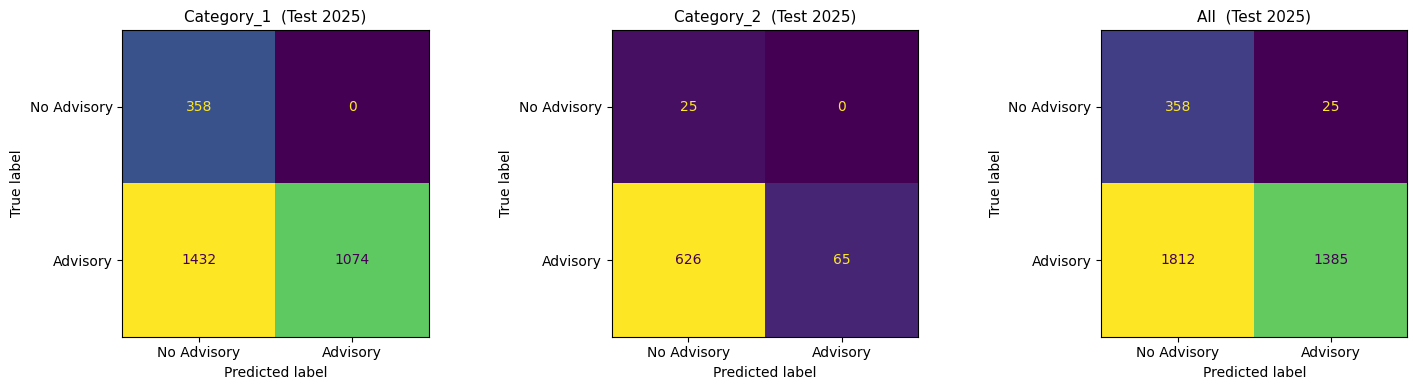

In [19]:
# ── 6b. Confusion matrices ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (cat, clf) in zip(axes, models.items()):
    s     = splits[cat]
    if len(s['y_test']) == 0:
        ax.set_visible(False)
        continue
    proba = clf.predict_proba(s['X_test'])[:, 1]
    pred  = (proba >= 0.5).astype(int)
    cm    = confusion_matrix(s['y_test'], pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Advisory', 'Advisory']).plot(ax=ax, colorbar=False)
    ax.set_title(f'{cat}  (Test 2025)', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

## 7 — Feature importance

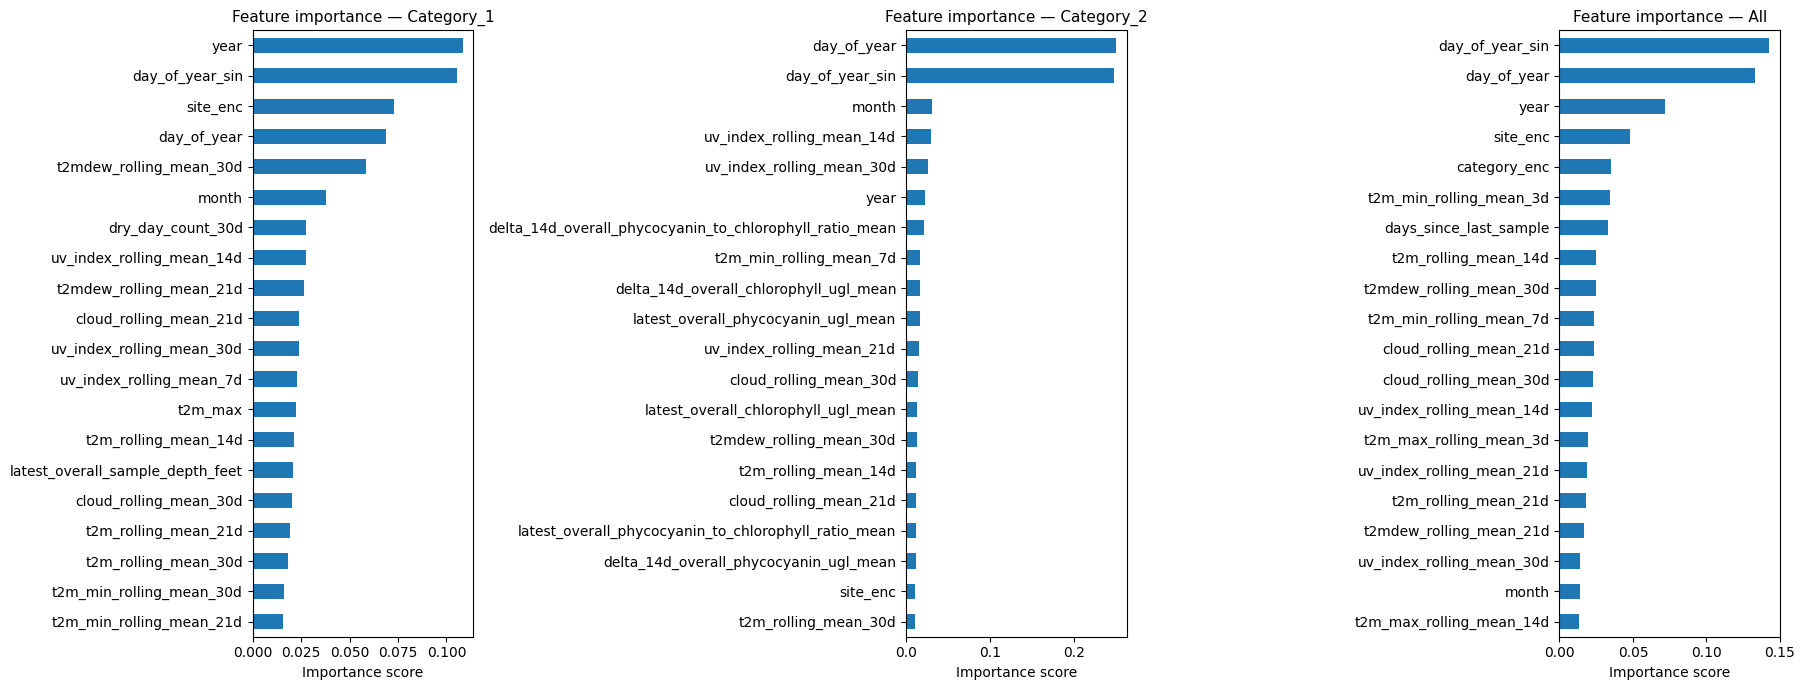

In [20]:
# ── 7. Feature importance (top 20 per model) ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, (cat, clf) in zip(axes, models.items()):
    importance = pd.Series(
        clf.feature_importances_, index=FEATURE_COLS
    ).sort_values(ascending=False).head(20)
    importance[::-1].plot(kind='barh', ax=ax)
    ax.set_title(f'Feature importance — {cat}', fontsize=11)
    ax.set_xlabel('Importance score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## 8 — Prediction function

Given a CSV of recent days for a site, this function returns:
- `advisory_probability` — confidence (0–100 %) that an advisory will be active in the next `FUTURE_WINDOW` days
- `predicted_advisory` — binary decision at the 50 % threshold
- `category` — which model was used

In [21]:
# ── 8. Prediction helper ──────────────────────────────────────────────────────
def predict_advisory(
    csv_path: str,
    threshold: float = 0.50,
    model_key: str = 'All',          # 'All', 'Category_1', or 'Category_2'
) -> pd.DataFrame:
    """
    Load a CSV of past-day rows, run the trained model, and return
    a DataFrame with one row per input row including:
      - site_name, date
      - advisory_probability  (0.0–1.0, multiply by 100 for %)
      - predicted_advisory    (0 or 1, at `threshold`)
      - confidence_pct        (human-readable % string)

    Parameters
    ----------
    csv_path   : path to a CSV file with the same columns as site_day_panel.csv
    threshold  : decision boundary (default 0.50)
    model_key  : which trained model to use ('All', 'Category_1', 'Category_2')
    """
    # --- load & encode
    incoming = pd.read_csv(csv_path, low_memory=False, parse_dates=['date'])
    incoming = incoming.sort_values(['site_name', 'date']).reset_index(drop=True)

    # encode categoricals with the same encoders used in training
    incoming['site_enc'] = (
        incoming['site_name']
        .map(dict(zip(le_site.classes_, le_site.transform(le_site.classes_))))
        .fillna(-1)               # unseen site → -1 (will get average prediction)
        .astype(int)
    )
    incoming['category_enc'] = (
        incoming['major_category']
        .map(dict(zip(le_cat.classes_, le_cat.transform(le_cat.classes_))))
        .fillna(-1)
        .astype(int)
    )

    # align feature columns
    X_new = incoming.reindex(columns=FEATURE_COLS)

    clf = models[model_key]
    proba = clf.predict_proba(X_new)[:, 1]

    result = incoming[['site_name', 'date']].copy()
    result['advisory_probability'] = proba
    result['predicted_advisory']   = (proba >= threshold).astype(int)
    result['confidence_pct']       = result['advisory_probability'].map(lambda p: f'{p*100:.1f}%')
    result['model_used']           = model_key

    return result


# ── smoke-test on the test slice ─────────────────────────────────────────────
# (write a small test CSV and run through the helper)
test_rows = df.loc[mask_test].head(20).copy()
test_rows.to_csv('/tmp/sample_input.csv', index=False)

demo = predict_advisory('/tmp/sample_input.csv', model_key='All')
print(demo[['site_name', 'date', 'confidence_pct', 'predicted_advisory']].to_string(index=False))

OSError: Cannot save file into a non-existent directory: '\tmp'

## 9 — Save models

In [ ]:
# ── 9. Persist models ────────────────────────────────────────────────────────
import joblib, os, json

os.makedirs('models', exist_ok=True)

for cat, clf in models.items():
    fname = f'models/advisory_gbm_{cat.replace(" ", "_")}.json'
    clf.save_model(fname)
    print(f'Saved: {fname}')

# save feature list and encoder mappings for inference
meta = {
    'feature_cols':      FEATURE_COLS,
    'future_window':     FUTURE_WINDOW,
    'target':            TARGET,
    'site_classes':      le_site.classes_.tolist(),
    'category_classes':  le_cat.classes_.tolist(),
    'train_end':         TRAIN_END,
    'val_end':           VAL_END,
    'test_start':        TEST_START,
}
with open('models/model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)
print('Saved: models/model_meta.json')